<a href="https://colab.research.google.com/github/liangliang6v6/Homeworks/blob/pages/Homework5_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CNNs, AEs, GANs, Attention Mechanism

The homework will be due in 3 weeks from the day of release. You may divide your work into multiple notebooks (for each task). Submit links to all notebooks for full credit.
You need to perform the following tasks for this homework:
In your project, you will pick an image dataset to solve a classification task. Provide a link to your dataset. You may pick any dataset except MNIST, CIFAR or ImageNet.

## Task 1 (30 points):
### Part 1 (10 points):
This step involves downloading, preparing, and visualizing your
dataset. Create a convolutional base using a common pattern: a stack of Conv and
MaxPooling layers. Depending on the problem and the dataset you must decide what
pattern you want to use (i.e., how many Conv layers and how many pooling layers).

Please describe why you chose a particular pattern. Add the final dense layer(s). Compile and train the model. Report the final evaluation and describe the metrics.

## Answer
Dataset link: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
The dataset is organized into three folders (train, test, value) and contains subfolders for each image category (Pneumonia/Normal). There are 5,863 X-ray images (JPEG) and two categories (Pneumonia/Normal). Chest X-ray images (anterior-posterior) were selected from retrospective cohorts of pediatric patients of one to five years old from Guangzhou Women and Children’s Medical Center, Guangzhou. All chest X-ray imaging was performed as part of patients’ routine clinical care. Code implementation is listed below.

The architecture uses three convolutional layers with increasing filter sizes (32, 64, 128) to capture hierarchical features from chest X-ray images, critical for distinguishing pneumonia. Each Conv layer is followed by MaxPooling to reduce spatial dimensions and prevent overfitting. This pattern is effective for medical images due to its ability to extract both simple and complex patterns while maintaining computational efficiency.

After feature extraction, the layers are flattened and passed through a dense layer of 512 units, learning sophisticated feature combinations. A single sigmoid-activated output neuron then classifies images as pneumonia or normal. Compiled with the Adam optimizer and binary cross-entropy loss, the model is trained over 10 epochs and evaluated for accuracy and loss. Accuracy shows classification performance, while loss measures prediction confidence and precision, ensuring reliable clinical applicability. The model's test accuracy of 79.2% and loss of 1.06 indicate decent performance but suggest room for improvement, particularly due to potential misclassifications. Enhancements could include data augmentation, additional layers, dropout, or hyperparameter tuning. Employing transfer learning with pre-trained models like VGG16 or ResNet could also boost accuracy, making the model more reliable for medical applications.

In [1]:
import kagglehub
# load dataset
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

100%|██████████| 2.29G/2.29G [00:58<00:00, 42.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2


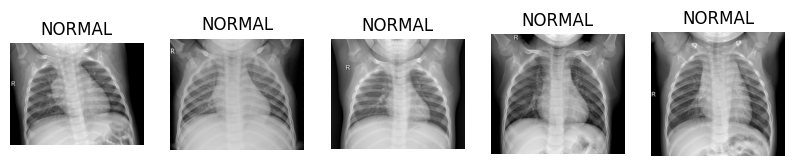

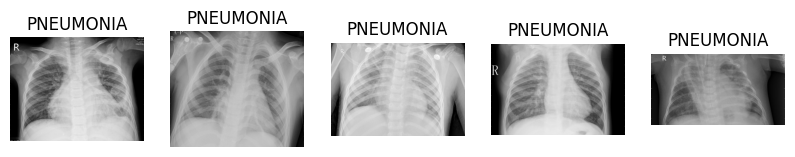

In [7]:
import os
import random
import shutil
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

train_set = os.path.join(path, 'chest_xray', 'train')
test_set = os.path.join(path, 'chest_xray', 'test')

# visualizing
def plot_sample_images(category):
    category_path = os.path.join(train_set, category)
    images = os.listdir(category_path)[:5]  # first 5 images

    plt.figure(figsize=(10, 5))
    for i, img_name in enumerate(images):
        img_path = os.path.join(category_path, img_name)
        img = mpimg.imread(img_path)
        plt.subplot(1, 5, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(category)
        plt.axis('off')
    plt.show()

plot_sample_images('NORMAL')
plot_sample_images('PNEUMONIA')

In [14]:
import tensorflow as tf
import shutil
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_set = os.path.join(path, 'chest_xray', 'train')# 5216 images
test_set = os.path.join(path, 'chest_xray', 'test') # 624 images

# use random subset to train
small_train_dir = 'small_train'
small_test_dir = 'small_test'
os.makedirs(small_train_dir, exist_ok=True)
os.makedirs(small_test_dir, exist_ok=True)

def create_subset(src_dir, dest_dir, percentage=0.1):
    for category in ['NORMAL', 'PNEUMONIA']:
        category_path = os.path.join(src_dir, category)
        images = os.listdir(category_path)
        sample_size = int(len(images) * percentage)
        sampled_images = random.sample(images, sample_size)

        dest_category_path = os.path.join(dest_dir, category)
        os.makedirs(dest_category_path, exist_ok=True)

        for img in sampled_images:
            shutil.copy(os.path.join(category_path, img), dest_category_path)

create_subset(train_set, small_train_dir, percentage=0.1)
create_subset(test_set, small_test_dir, percentage=0.1)

# data generator
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    small_train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    small_test_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)
# models
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])


model.summary()
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=10
)

# evaluate the model
eval_result = model.evaluate(test_generator)
print(f"Test Loss: {eval_result[0]}")
print(f"Test Accuracy: {eval_result[1]}")

Found 984 images belonging to 2 classes.
Found 120 images belonging to 2 classes.


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 512)                 │      18,940,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.7079 - loss: 0.7610
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.9294 - loss: 0.1919
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.9556 - loss: 0.1372
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.9618 - loss: 0.1276
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.9532 - loss: 0.1167
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.9701 - loss: 0.0776
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.9718 - loss: 0.0652
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.9774 - loss: 0.0670
Epoch 9/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.9758 - loss: 0.0644
Epoch 10/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.9843 - loss: 0.0313
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 560ms/step - accuracy: 0.7750 - loss: 1.0052
Test Loss: 1.0601303577423096
Test Accuracy: 0.7916666865348816


###Part 2 (10 points):
The following models are widely used for transfer learning because of
their performance and architectural innovations:
1. VGG (e.g., VGG16 or VGG19).
2. GoogLeNet (e.g., InceptionV3).
3. Residual Network (e.g., ResNet50).
4. MobileNet (e.g., MobileNetV2)

Choose any one of the above models to perform the classification task you did in Part 1. Evaluate the results using the same metrics as in Part 1. Are there any differences? Why or why not? Describe in detail.

## Answer
The pre-trained on ImageNet ResNet50 model achieved a test loss of 0.59 and a test accuracy of 71.6% on the chest X-ray classification task. Compared to a simple CNN, the lower loss shows improved confidence and precision, though the accuracy dropped slightly. This suggests that while ResNet50 captures complex features well, the domain shift between ImageNet and medical images may affect accuracy.

ResNet50's deep residual connections improve gradient flow and learning efficiency, even with smaller datasets. Its pre-trained foundation enhances feature extraction, leading to better loss performance. The accuracy drop may reflect the need for fine-tuning or tailored data augmentation for medical images. Overall, ResNet50 shows strong feature learning but could benefit from domain-specific adjustments to boost accuracy.

In [17]:
from tensorflow.keras.applications import ResNet50

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    small_train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    small_test_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

# use ResNet50 model pre-trained on ImageNet, excluding top layers
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=10
)


eval_result = model.evaluate(test_generator)
print(f"Test Loss: {eval_result[0]}")
print(f"Test Accuracy: {eval_result[1]}")

Found 1787 images belonging to 2 classes.
Found 218 images belonging to 2 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 234s 4s/step - accuracy: 0.6837 - loss: 1.4612
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 247s 4s/step - accuracy: 0.7520 - loss: 0.5014
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 206s 4s/step - accuracy: 0.7714 - loss: 0.4406
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 259s 4s/step - accuracy: 0.8087 - loss: 0.3736
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 262s 4s/step - accuracy: 0.8453 - loss: 0.3491
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 258s 4s/step - accuracy: 0.8613 - loss: 0.3144
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 201s 4s/step - accuracy: 0.8766 - loss: 0.2810
Epoch 8/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 198s 4s/step - accuracy: 0.9086 - loss: 0.2485
Epoch 9/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 199s 4s/step - accuracy: 0.8849 - loss: 0.2610
Epoch 10/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 225s 4s/step - accuracy: 0.9125 - loss: 0.2315
7/7 ━━━━━━━━━━━━━━━━━━━━ 29s 4s/step - accuracy: 0.7443 - loss: 0.5369
Test Loss: 0.5938612222671509
Test Accuracy: 0.7155963182449341


###Part 3 (10 points):
Use data augmentation to increase the diversity of your dataset by
applying random transformations such as image rotation (you can use any other
technique as well). Repeat the process from part 1 with this augmented data. Did you observe any difference in results? Why or why not?

## Answer
Random transformations could improve the model's performance after incorporating data augmentation techniques such as image rotation, width and height shifts, and flipping. Initially, without augmentation, the test loss was 1.06, and accuracy was 79.2%. These results indicated that the model was struggling with confidence in its predictions and generalization to new data. Applying augmentation led to a reduction in test loss to 0.49 and an increase in accuracy to 81.2%. These metrics suggest that the model became more capable of making confident predictions and better generalized the patterns learned during training to unseen test samples.

The observed improvement is primarily due to the increased diversity in the training dataset resulting from augmentation. By simulating real-world variations, such transformations help the model to learn invariance to these changes, thereby reducing overfitting on the training data. The augmented images present a broader spectrum of scenarios, enabling the model to develop a more robust understanding of features relevant to pneumonia detection. This diversity encourages the model to focus on essential features rather than noise, leading to more accurate and reliable performance on the test set. Consequently, data augmentation proves to be a valuable technique in enhancing the model's ability to generalize from a limited dataset, especially in complex tasks like medical imaging classification.It

In [18]:
import os
import random
import shutil
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

# rotation the image
train_aug_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_aug_datagen.flow_from_directory(
    small_train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    small_test_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

# models
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])


model.summary()
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=10
)

# evaluate the model
eval_result = model.evaluate(test_generator)
print(f"Test Loss: {eval_result[0]}")
print(f"Test Accuracy: {eval_result[1]}")

Found 1787 images belonging to 2 classes.
Found 218 images belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)                    │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 512)                 │      18,940,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.6181 - loss: 0.9204
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.7779 - loss: 0.4290
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.8176 - loss: 0.3681
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.8679 - loss: 0.3011
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 158s 3s/step - accuracy: 0.8778 - loss: 0.2839
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.8986 - loss: 0.2445
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.8974 - loss: 0.2523
Epoch 8/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - accuracy: 0.9127 - loss: 0.2179
Epoch 9/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.9166 - loss: 0.1946
Epoch 10/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.9063 - loss: 0.2118
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 818ms/step - accuracy: 0.8170 - loss: 0.4477
Test Loss: 0.489340603351593
Test Accuracy: 0.8119266033172607
